In [3]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import tools.particle_swarm_optimization as pso
import tools.particle_swarm_optimization_plot as pso_plt
import tools.peristimulus_time_histogram as psth

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [95]:
# calculo cantidad de sinapsis

N_scaling, K_scaling = 0.1, 0.1

# internas
conn_probs = np.array(
        [
            [0.1009, 0.1689, 0.0437, 0.0818, 0.0323, 0.,     0.0076, 0.],       # L23E
            [0.1346, 0.1371, 0.0316, 0.0515, 0.0755, 0.,     0.0042, 0.],       # L23I
            [0.0077, 0.0059, 0.0497, 0.135,  0.0067, 0.0003, 0.0453, 0.],       # L4E
            [0.0691, 0.0029, 0.0794, 0.1597, 0.0033, 0.,     0.1057, 0.],       # L4I
            [0.1004, 0.0622, 0.0505, 0.0057, 0.0831, 0.3726, 0.0204, 0.],       # L5E
            [0.0548, 0.0269, 0.0257, 0.0022, 0.06,   0.3158, 0.0086, 0.],       # L5I
            [0.0156, 0.0066, 0.0211, 0.0166, 0.0572, 0.0197, 0.0396, 0.2252],   # L6E
            [0.0364, 0.001,  0.0034, 0.0005, 0.0277, 0.008,  0.0658, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )

conn_probs_v2= np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0894, 0.1697, 0.0043, 0.,     0.1157, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )


print('****************')
print('Synap internas')
full_num_neurons = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])
full_num_neurons_v2 = np.array([22051,  6219, 11421, 2855, 4461, 979,  13966, 2859])

prod = np.outer(full_num_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
num_neurons = np.round(full_num_neurons*N_scaling).astype(int)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)



print('****************')
print('Synap thalamicas')

conn_probs_th = np.array([0.0, 0.0, 0.0983, 0.0619, 0.0, 0.0, 0.0512, 0.0196])
prod = np.outer(902, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs_th) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int)
syn_int = np.round(full_syn_sum/full_num_neurons)
print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int)
syn_int = np.round(syn_sum/num_neurons)
print(syn_int)


print('****************')
print('Synap Lateral')


conn_probs = np.array(
                [[0.06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23E
                [0.03, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23I
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L4E
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L4I
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5E
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5I
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L6E
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])    # L6I
                # L2E  L2I  L4E  L4I  L5E  L5I  L6E  L6I}

prod = np.outer(full_num_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)



print('****************')
print('Synap FF')


conn_probs= np.array(
            [[0.0,    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L23E
             [0.0,    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # L23I
             [0.1,    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L4E
             [0.065,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L4I
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L5E
             [0.0,   0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L5I
             [0.1689, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L6E
             [0.1371, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])


prod = np.outer(full_num_neurons, full_num_neurons_v2)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons_v2)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
num_neurons_v2 = np.round(full_num_neurons_v2*N_scaling).astype(int)

syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
syn_int = np.round(syn_sum/num_neurons_v2)

print(syn_int)

print('****************')
print('Synap FB')


conn_probs = np.array(
            [[0.0, 0.0, 0.0, 0.0, 0.06, 0.0, 0.06, 0.0],     # L23E
             [0.0, 0.0, 0.0, 0.0, 0.03, 0.0, 0.03, 0.0],     # L23I
             [0.0, 0.0, 0.0, 0.0, 0.0,  0.0, 0.0,  0.0],     # L4E
             [0.0, 0.0, 0.0, 0.0, 0.0,  0.0, 0.0,  0.0],     # L4I
             [0.0, 0.0, 0.0, 0.0, 0.06, 0.0, 0.06, 0.0],     # L5E
             [0.0, 0.0, 0.0, 0.0, 0.03, 0.0, 0.03, 0.0],     # L5I
             [0.0, 0.0, 0.0, 0.0, 0.02, 0.0, 0.02,  0.0],     # L6E
             [0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.01,  0.0]])

prod = np.outer(full_num_neurons_v2, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)

print('****************')
print('Synap internas V2')

conn_probs= np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0854, 0.1647, 0.0043, 0.,     0.1077, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )*0.8

prod = np.outer(full_num_neurons_v2, full_num_neurons_v2)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons_v2)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)

syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
num_neurons = np.round(full_num_neurons_v2*N_scaling).astype(int)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)


print('****************')
print('Ext indegreees')

K_ext = np.array([1600, 1500, 2100, 1900, 2000, 1900, 2900, 2100])

ext_indegrees = np.round(K_ext * K_scaling).astype(int)
print(ext_indegrees)

K_ext = np.array([1700, 1500, 1550, 1420, 2050, 1900, 2800, 2100])
ext_indegrees = np.round(K_ext * K_scaling).astype(int)
print(ext_indegrees)


****************
Synap internas
[4995. 5285. 2806. 5888. 4944. 2736. 2564. 2434.]
[500. 529. 281. 589. 494. 275. 256. 243.]
****************
Synap thalamicas
[[ 0.  0. 93. 58.  0.  0. 47. 18.]]
[[0. 0. 9. 6. 0. 0. 5. 2.]]
****************
Synap Lateral
[1280.  630.    0.    0.    0.    0.    0.    0.]
[128.  63.   0.   0.   0.   0.   0.   0.]
****************
Synap FF
[   0.    0. 4458. 2844.    0.    0. 4205. 3353.]
[  0.   0. 446. 284.   0.   0. 420. 335.]
****************
Synap FB
[1270.  625.    0.    0. 1095.  539.  377.  188.]
[127.  63.   0.   0. 110.  54.  38.  19.]
****************
Synap internas V2
[4476. 4797. 1789. 3759. 3798. 2254. 2356. 2075.]
[448. 480. 179. 375. 380. 225. 235. 207.]
****************
Ext indegreees
[160 150 210 190 200 190 290 210]
[170 150 155 142 205 190 280 210]


Text(50.722222222222214, 0.5, 'To')

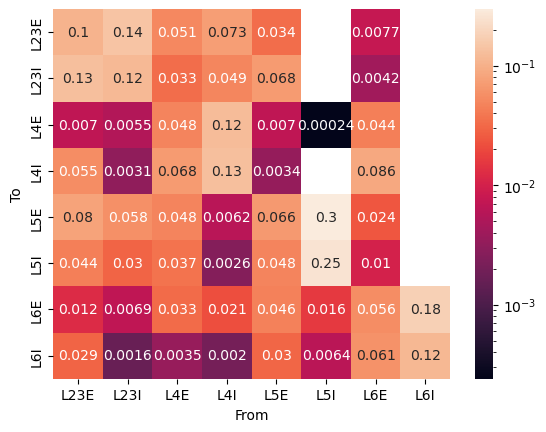

In [6]:
# mapa de calor de la matriz de conectividad

prob = np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0854, 0.1647, 0.0043, 0.,     0.1077, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )*0.8

ax_lab = ['L23E', 'L23I', 'L4E', 'L4I', 'L5E', 'L5I', 'L6E', 'L6I']

glue = sns.load_dataset("glue").pivot(index="Model", columns="Task", values="Score")
sns.heatmap(prob, annot=True, norm=LogNorm(), xticklabels=ax_lab, yticklabels=ax_lab)
plt.xlabel('From')
plt.ylabel('To')



Interval to compute firing rates: [   0 1500] ms
Mean rates: [0.889 3.184 3.925 5.285 4.013 8.185 0.774 7.155 0.889 3.14  3.888 5.268
 3.635 8.225 0.744 7.116 0.943 3.156 3.857 5.269 3.497 8.272 0.746 7.122
 0.942 3.167 3.843 5.251 3.621 8.266 0.73  7.13  1.701 3.559 5.273 8.962
 4.065 7.262 0.683 8.507] spikes/s
Standard deviation of rates: [1.048 2.186 2.69  3.278 3.168 4.603 1.087 3.982 1.048 2.204 2.78  3.574
 3.075 4.996 1.096 3.935 1.098 2.196 2.729 3.585 2.912 4.881 1.063 3.97
 1.124 2.21  2.7   3.221 2.973 4.705 1.036 4.103 1.798 2.814 3.887 5.326
 3.059 4.191 1.043 5.036] spikes/s


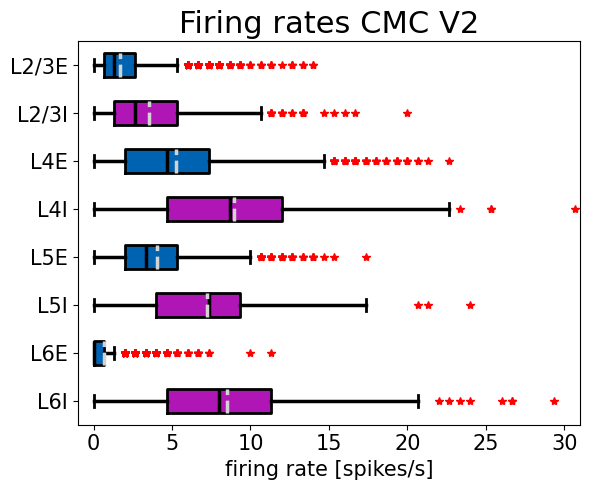

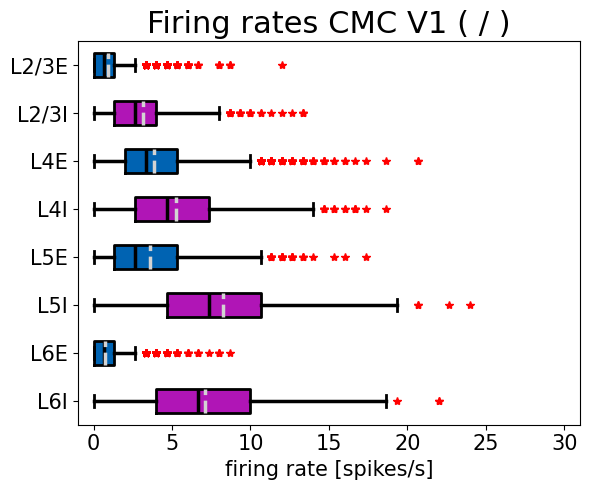

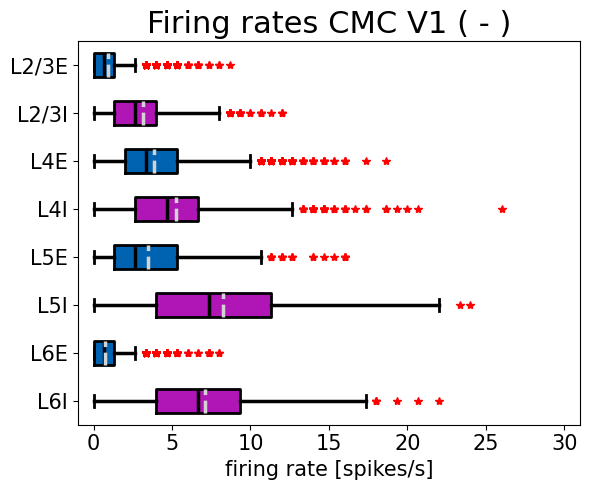

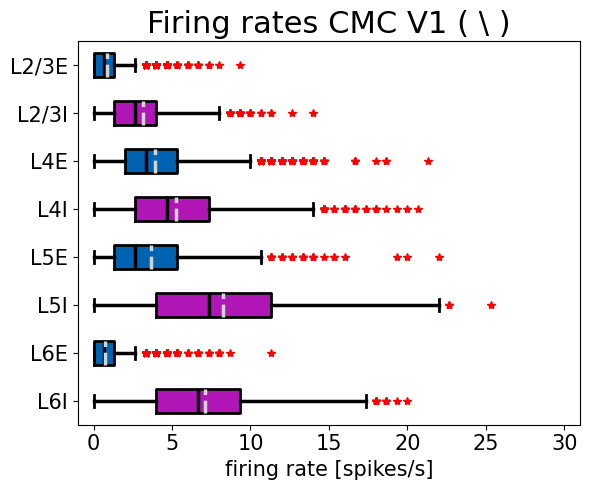

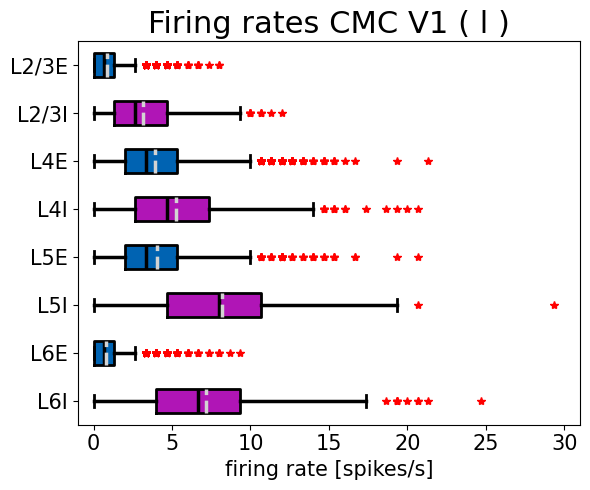

In [31]:
## Raster plot y firing rate
## por simulación

from utils import helpers
import scipy.stats as stats

data_path = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20250120155142/'

populations = ['L23E', 'L23I', 'L4E', 'L4I', 'L5E', 'L5I', 'L6E', 'L6I']
names = ['CMC V1 ( l )', 'CMC V1 ( \\ )', 'CMC V1 ( - )', 'CMC V1 ( / )', 'CMC V2']
#names = ['CMC V1 ( l )', 'CMC V1 ( \\ )', 'CMC V1 ( - )', 'CMC V1 ( / )']
#names = ['CMC V1 ( l )']
#names = ['']

all_pops = []

for i in names:
    all_pops += list(map(lambda pop: f"{pop}",populations))

t_sim = 1500

if True:
    firing_rates_interval = np.array([0, t_sim])

    print('Interval to compute firing rates: {} ms'.format(firing_rates_interval))
    helpers.firing_rates(
        data_path,
        'spike_recorder',
        0,
        t_sim)
    helpers.boxplot(data_path, all_pops, 'firing_rate_',  False, True, names)

if False:
    id_sim = data_path.split("/")[-1]
    helpers.plot_raster(
        data_path,
        'spike_recorder',
        0,
        t_sim,
        0.2,
        all_pops,
        id_sim)


######################## test estadistico

if False:

    data_path1 = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 4 mcc 4000 ms/'
    data_path2 = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 5 mcc 4000 ms/'

    pval_1, pval_2 = [], []

    for i in range(8):
        g1 = np.loadtxt(os.path.join(data_path1, ('rate' + str(i) + '.dat')))
        g2 = np.loadtxt(os.path.join(data_path2, ('rate' + str(i) + '.dat')))
        g3 = np.loadtxt(os.path.join(data_path2, ('rate' + str(i+32) + '.dat')))

        n, p = stats.mannwhitneyu(g1,g2)
        pval_1.append(p)

        n, p = stats.mannwhitneyu(g1,g3)
        pval_2.append(p)

    # Redondear a 2 decimales
    pval_1r = [round(valor, 4) for valor in pval_1]  
    pval_2r = [round(valor, 4) for valor in pval_2]  
    print(pval_1r)
    print(pval_2r)
        

/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120195241
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120200043
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120201003
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120202046
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120203036
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120204035
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120205038
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30hz/20250120210042
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_30h

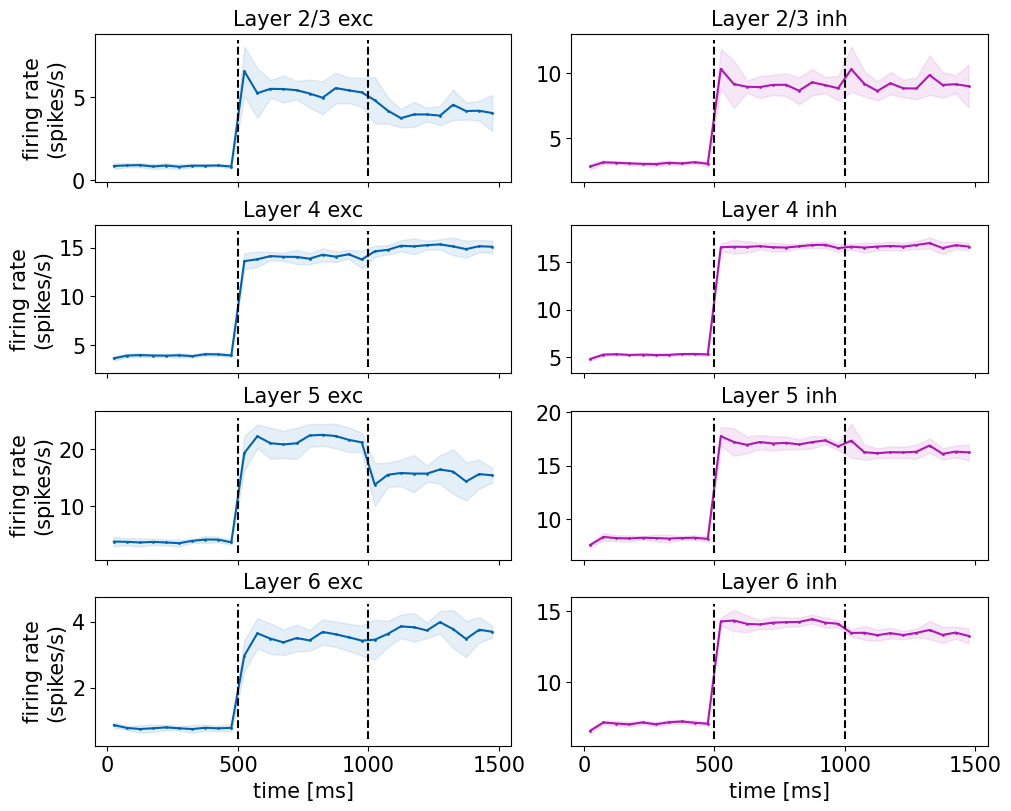

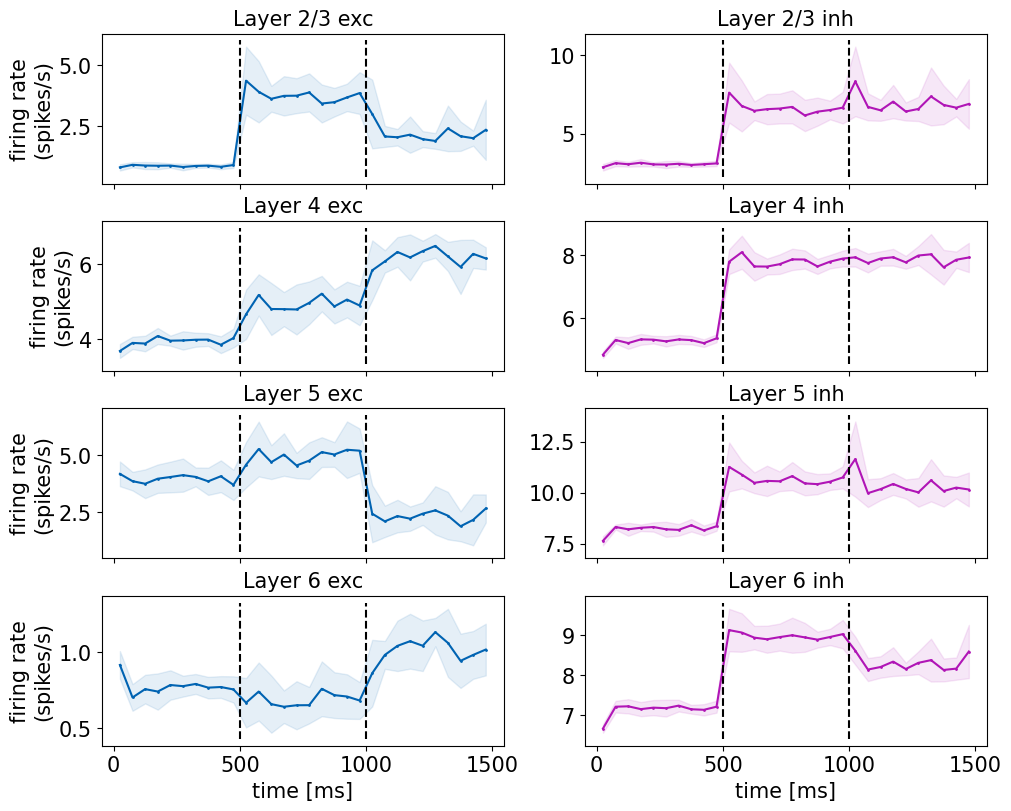

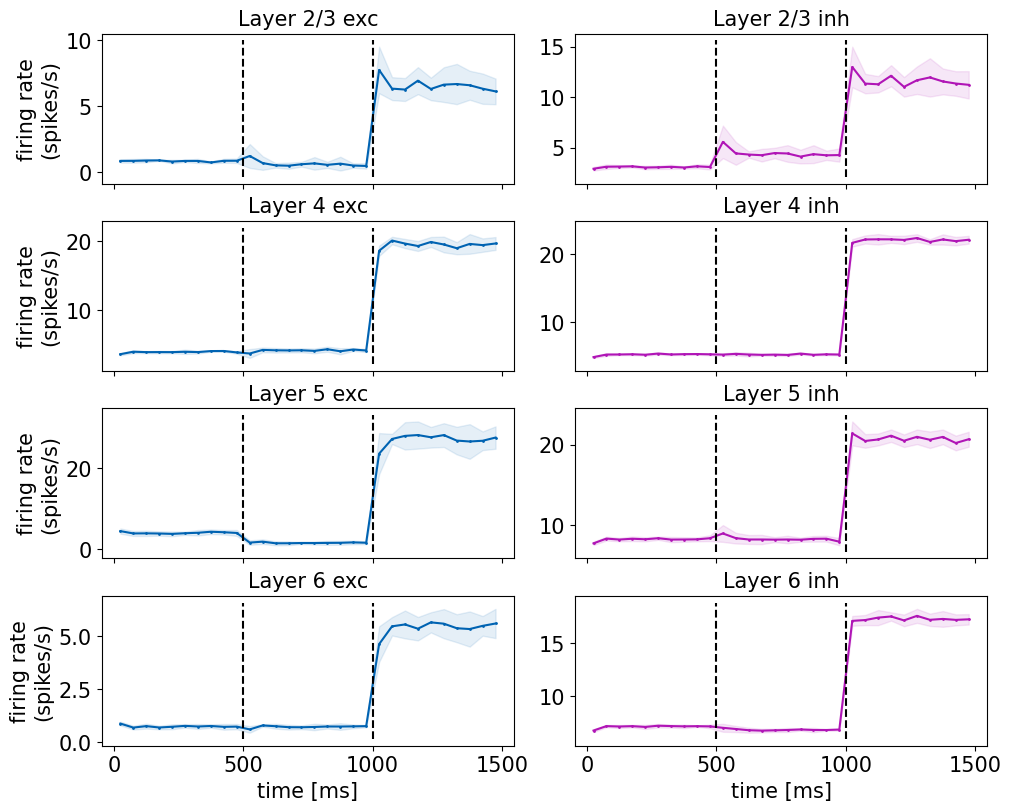

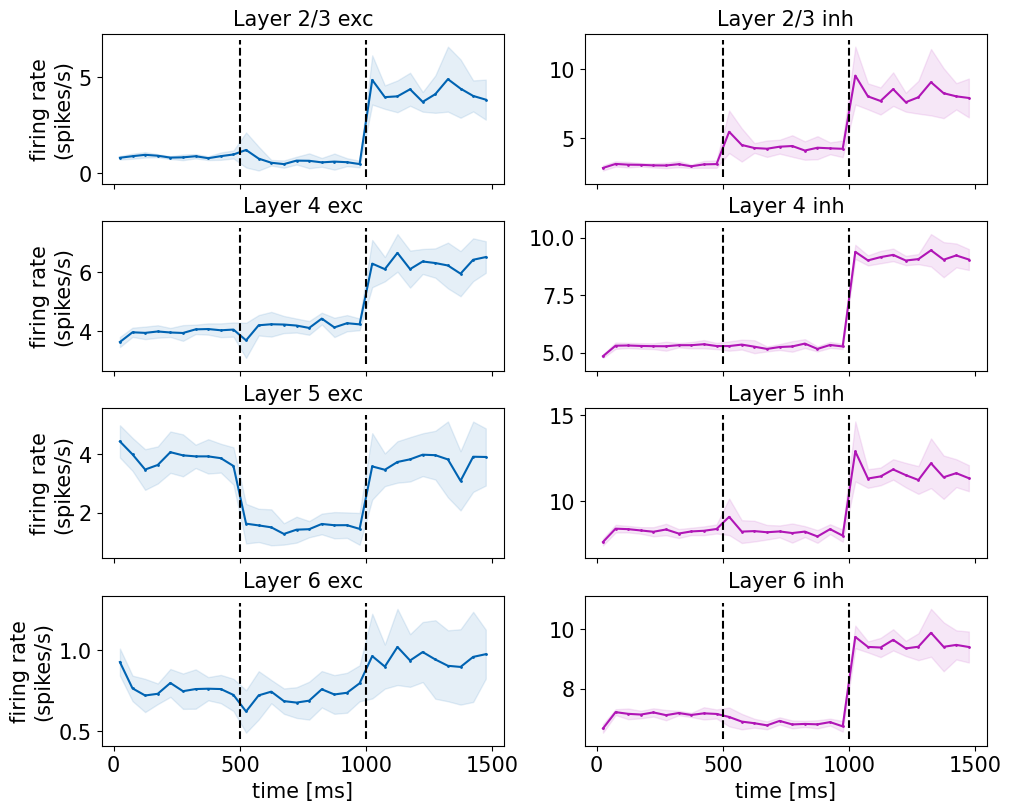

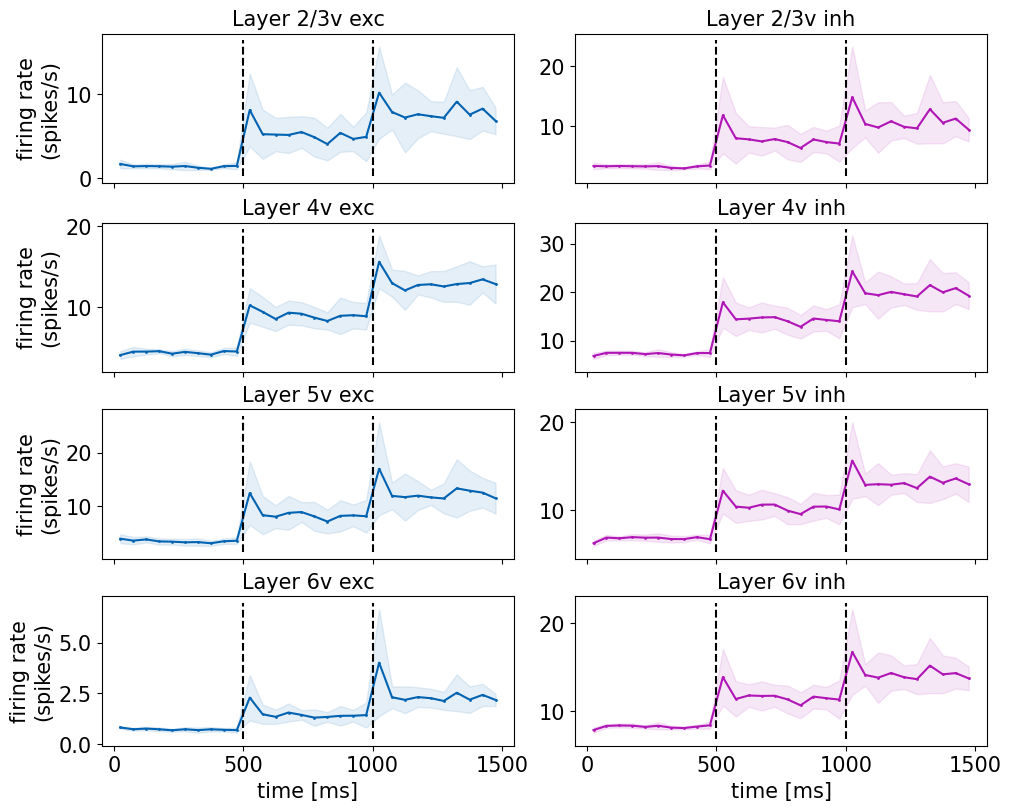

In [21]:
# PSTH carpeta
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/ECRF_v2_20hz_30hz')
#folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_4'

#fp = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20250112230001/'
l_bin = 50
t_sim = 1500

#psth.PSTH_data(fp, 0.2, 1500, l_bin)
#psth.PSTH_plot_tog(fp, 1500, l_bin)

psth.PSTH_folders_data(folder_path, 0.2, t_sim, l_bin) 

psth.PSTH_figure(folder_path, t_sim, l_bin, 0)
psth.PSTH_figure(folder_path, t_sim, l_bin, 1)
psth.PSTH_figure(folder_path, t_sim, l_bin, 2)
psth.PSTH_figure(folder_path, t_sim, l_bin, 3)

psth.PSTH_figure(folder_path, t_sim, l_bin, 4)
psth.PSTH_figure(folder_path, t_sim, l_bin, 5)
#psth.PSTH_plot_tog(folder_path, t_sim, l_bin)

#psth.PSTH_plot(folder_path, 1500, l_bin)



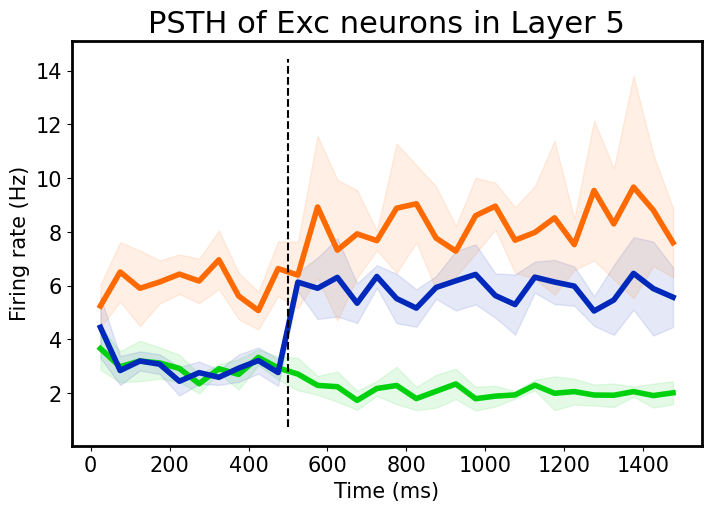

In [25]:
# PSTH figuras varias curvas

folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/CRF_v2_05hz')
t_sim = 1500
l_bin = 50

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))

#################
if False:
    subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'] == '2/3a')][names[3:]].values

    fig, ax = plt.subplots(layout='constrained', figsize=(7,5), sharex=True)

    color = ['#0028BA','#0046B6','#0063B2','#008CAD']
    #color = ['#CD0074','#FF0000','#FF7400','#FFAA00','#FFD300','#FFFF00']
    for i in range(0, len(subset),2):
    
        y = subset[i]
        ci = subset[i+1]

        ax.plot(bin_centers, y, '.-',lw=4, color=color[int(i/2)], markersize=2)
        ax.fill_between(bin_centers, (y-ci), (y+ci), color=color[int(i/2)], alpha=.1)

    bot, top = ax.get_ylim()  # return the current ylim
    ax.plot([500, 500], [bot, top], 'k--', lw=2)
    #ax.plot([1000, 1000], [bot, top], 'k--', lw=2)

    plt.xlabel('Time (ms)',fontsize=15)
    plt.ylabel('Firing rate (Hz)',fontsize=15)
    plt.title('PSTH of Exc neurons in Layer 4',fontsize=22)
    plt.xticks(fontsize = 15) 
    plt.yticks(fontsize = 15) 

    for spine in ax.spines.values():
        spine.set_linewidth(2) 
    plt.show()

####################

if True:
    subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'].isin(['5a', '5c', '5v2']))][names[3:]].values
    #subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'].isin(['4a', '4c']))][names[3:]].values

    fig, ax = plt.subplots(layout='constrained', figsize=(7,5), sharex=True)


    y, ci= subset[2], subset[3]
    ax.plot(bin_centers, y, '.-',lw=4, color='#00D10E', markersize=2)
    ax.fill_between(bin_centers, (y-ci), (y+ci), color='#00D10E', alpha=.1)

    y, ci= subset[0], subset[1]
    ax.plot(bin_centers, y, '.-', lw=4, color='#0028BA', markersize=2)
    ax.fill_between(bin_centers, (y-ci), (y+ci), color='#0028BA', alpha=.1)

    y, ci= subset[4], subset[5]
    ax.plot(bin_centers, y, '.-',lw=4, color='#FF6A00', markersize=2)
    ax.fill_between(bin_centers, (y-ci), (y+ci), color='#FF6A00', alpha=.1)


    bot, top = ax.get_ylim()  # return the current ylim  color='#FF6A00'
    ax.plot([500, 500], [bot, top], 'k--')
    #ax.plot([1000, 1000], [bot, top], 'k--')

    plt.xlabel('Time (ms)',fontsize=15)
    plt.ylabel('Firing rate (Hz)',fontsize=15)
    plt.title('PSTH of Exc neurons in Layer 5',fontsize=22)
    plt.xticks(fontsize = 15) 
    plt.yticks(fontsize = 15) 

    for spine in ax.spines.values():
        spine.set_linewidth(2) 
    plt.show()

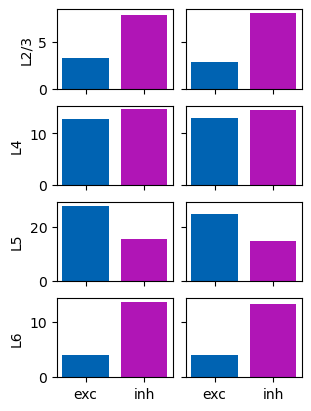

In [478]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result2_3'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(4,2,layout='constrained', figsize=(3,4), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']

for j,jj in enumerate(range(0,16,4)):

    ax[j,0].bar(0, subset[jj,1],color='#0063B2')
    ax[j,0].bar(1, subset[jj+2,1],color='#b015b6')
    ax[j,0].set_ylabel(layer[j])

    ax[j,1].bar(0, subset[jj,2],color='#0063B2')
    ax[j,1].bar(1, subset[jj+2,2],color='#b015b6')

ax[1,0].set_xticks([0,1],['exc','inh'])


# plt.xlabel('Time (ms)')
# plt.ylabel('Firing rate (Hz)')
# plt.title('PSTH L5 exc')
# plt.show()

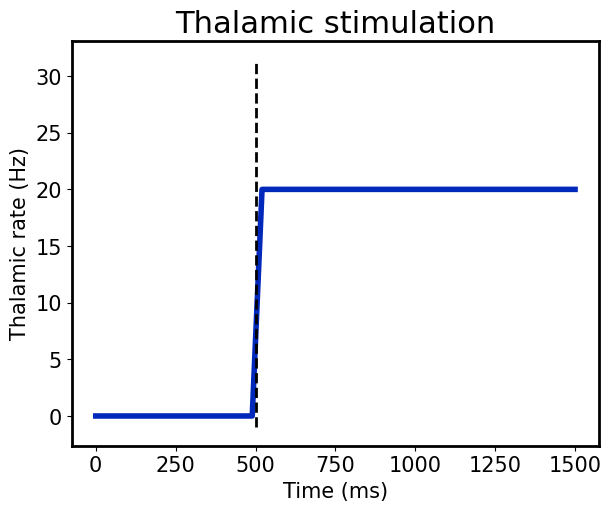

In [12]:
fig, ax = plt.subplots(layout='constrained', figsize=(6,5), sharex=True, sharey='row')

time = np.linspace(0,1500)

stim1, stim2, stim3, stim4 = [], [], [], []
for i in time:
    if i >= 500:
        stim1.append(30)
        stim2.append(20)
        stim3.append(10)
        stim4.append(5)
    else:
        stim1.append(0)
        stim2.append(0)
        stim3.append(0)
        stim4.append(0)

    #if i >= 1000:
    ##    stim2.append(30)
    #else:
    #    stim2.append(0)


color = ['#0028BA','#0046B6','#0063B2','#008CAD']
#color = ['#0028BA','#00D10E','#0063B2','#008CAD']

#ax.plot(time,stim1,lw=4,color=color[0])
ax.plot(time,stim2,lw=4,color=color[0])
#ax.plot(time,stim3,lw=4,color=color[2])
#ax.plot(time,stim4,lw=4,color=color[3])

bot, top = ax.get_ylim()  # return the current ylim

ax.plot([500, 500], [bot, 31.5], 'k--', lw=2)
#ax.plot([1000, 1000], [bot, 41.5], 'k--', lw=2)

plt.xlabel('Time (ms)',fontsize=15)
plt.ylabel('Thalamic rate (Hz)',fontsize=15)
plt.title('Thalamic stimulation',fontsize=22)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500],[0, 250, 500, 750, 1000, 1250, 1500])

plt.xticks(fontsize = 15) 
plt.yticks(fontsize = 15) 

for spine in ax.spines.values():
    spine.set_linewidth(2) 
plt.show()